In [6]:

import pandas as pd
import numpy as np
import heapq
from math import radians, sin, cos, sqrt, atan2
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
AVG_SPEED_KMH      = 40.0
ALS_RESERVE        = 2        # minimum ALS held free for HIGH severity
REPOSITION_SPEED   = 50.0     # slightly faster when returning home (empty)
SEV_PRIORITY       = {'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}
SEV_WEIGHT         = {'HIGH': 1.0, 'MEDIUM': 0.7, 'LOW': 0.4}
TYPE_PENALTY       = {'ALS': {'HIGH': 0, 'MEDIUM': 5, 'LOW': 10},
                       'BLS': {'HIGH': 15, 'MEDIUM': 0, 'LOW': 0}}

# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    φ1, φ2 = radians(float(lat1)), radians(float(lat2))
    dφ = radians(float(lat2) - float(lat1))
    dλ = radians(float(lon2) - float(lon1))
    a = sin(dφ/2)**2 + cos(φ1)*cos(φ2)*sin(dλ/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

def eta_min(lat1, lon1, lat2, lon2, speed=AVG_SPEED_KMH):
    if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return np.inf
    return haversine_km(lat1, lon1, lat2, lon2) / speed * 60.0

# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
print("Loading data…")
patients_df = pd.read_csv('nashik_synthetic_stage3.csv')
patients_df['incident_time'] = pd.to_datetime(patients_df['incident_time'])
patients_df = patients_df.sort_values('incident_time').reset_index(drop=True)

hotspots_df = pd.read_csv('nashik_hotspots_stage1.csv')

hospitals_raw = pd.read_excel('HOSPITALS_DATA_FINAL.xlsx')
hospitals_raw.columns = hospitals_raw.columns.str.strip()
if hospitals_raw.columns.duplicated().any():
    hospitals_raw = hospitals_raw.loc[:, ~hospitals_raw.columns.duplicated()]
hospitals = hospitals_raw.dropna(subset=['LATITUDE','LONGITUDE']).copy()
hospitals = hospitals.rename(columns={'HOSPITAL NAME':'hospital_name','LATITUDE':'lat','LONGITUDE':'lon'})
hospitals = hospitals.reset_index(drop=True)
hospitals['hospital_id'] = ['H' + str(i) for i in range(len(hospitals))]

SPECIALTY_COLS = ['CARDIOLOGY','UROLOGY','BURNS','CRITICAL','Neurology',
                  'Neurosurgery','Polytrauma','Pulmonology','Medicine','General',
                  'Pediatrics','ORTHOPEDICS','Gynaecology','Nephrology','CARDIOTHORACIC']
for col in SPECIALTY_COLS:
    if col not in hospitals.columns:
        hospitals[col] = 0
    hospitals[col] = pd.to_numeric(hospitals[col], errors='coerce').fillna(0)

hospitals['available_beds'] = pd.to_numeric(
    hospitals.get('Total Bed count', 20), errors='coerce').fillna(20).astype(int)
hospitals['total_beds']       = hospitals['available_beds'].copy()
hospitals['patients_assigned'] = 0

print(f"  Patients : {len(patients_df)}")
print(f"  Hospitals: {len(hospitals)}")

# ─────────────────────────────────────────────────────────────────────────────
# AMBULANCE DEPLOYMENT  (demand-proportional + severity-weighted)
# ─────────────────────────────────────────────────────────────────────────────
zone_coords = patients_df.groupby('zone')[['patient_lat','patient_lon']].mean().reset_index()
zone_coords.columns = ['zone','lat','lon']
deploy = hotspots_df.merge(zone_coords, on='zone', how='left').dropna(subset=['lat','lon'])

total_inc    = deploy['incident_count'].sum()
total_severe = deploy['severe_count'].sum()
deploy = deploy.copy()
deploy['d_w'] = deploy['incident_count'] / total_inc
deploy['s_w'] = deploy['severe_count']   / total_severe

# ─────────────────────────────────────────────────────────────────────────────
# EXACT ALS/BLS ALLOCATION
# ─────────────────────────────────────────────────────────────────────────────
TOTAL_ALS, TOTAL_BLS = 11, 35
TOTAL_AMB = TOTAL_ALS + TOTAL_BLS

deploy = deploy.copy()

deploy['d_w'] = deploy['incident_count'] / deploy['incident_count'].sum()
deploy['s_w'] = deploy['severe_count'] / deploy['severe_count'].sum()

# Initial rounded allocation
deploy['als_alloc'] = (deploy['s_w'] * TOTAL_ALS).round().astype(int)
deploy['bls_alloc'] = (deploy['d_w'] * TOTAL_BLS).round().astype(int)

# Fix ALS exactly
while deploy['als_alloc'].sum() < TOTAL_ALS:
    idx = deploy.sort_values('s_w', ascending=False).index[0]
    deploy.loc[idx, 'als_alloc'] += 1

while deploy['als_alloc'].sum() > TOTAL_ALS:
    idx = deploy[deploy['als_alloc'] > 0].sort_values('s_w', ascending=True).index[0]
    deploy.loc[idx, 'als_alloc'] -= 1

# Fix BLS exactly
while deploy['bls_alloc'].sum() < TOTAL_BLS:
    idx = deploy.sort_values('d_w', ascending=False).index[0]
    deploy.loc[idx, 'bls_alloc'] += 1

while deploy['bls_alloc'].sum() > TOTAL_BLS:
    idx = deploy[deploy['bls_alloc'] > 0].sort_values('d_w', ascending=True).index[0]
    deploy.loc[idx, 'bls_alloc'] -= 1

deploy['total_alloc'] = deploy['als_alloc'] + deploy['bls_alloc']

# Build fleet
ambulances = []
amb_id = 0
SIM_START = patients_df['incident_time'].min()

for _, row in deploy.iterrows():
    for _ in range(int(row['als_alloc'])):
        ambulances.append({
            'amb_id': f'ALS_{amb_id:03d}', 'type': 'ALS',
            'lat': row['lat'], 'lon': row['lon'],
            'home_lat': row['lat'], 'home_lon': row['lon'],
            'home_zone': row['zone'], 'status': 'IDLE',
            'available_at': SIM_START
        })
        amb_id += 1
    for _ in range(int(row['bls_alloc'])):
        ambulances.append({
            'amb_id': f'BLS_{amb_id:03d}', 'type': 'BLS',
            'lat': row['lat'], 'lon': row['lon'],
            'home_lat': row['lat'], 'home_lon': row['lon'],
            'home_zone': row['zone'], 'status': 'IDLE',
            'available_at': SIM_START
        })
        amb_id += 1

# Trim / pad to exactly 46
while len(ambulances) > TOTAL_AMB:
    ambulances.pop()
top = deploy.iloc[0]
while len(ambulances) < TOTAL_AMB:
    ambulances.append({
        'amb_id': f'BLS_{amb_id:03d}', 'type': 'BLS',
        'lat': top['lat'], 'lon': top['lon'],
        'home_lat': top['lat'], 'home_lon': top['lon'],
        'home_zone': top['zone'], 'status': 'IDLE',
        'available_at': SIM_START
    })
    amb_id += 1

amb_df    = pd.DataFrame(ambulances)
als_count = (amb_df['type'] == 'ALS').sum()
bls_count = (amb_df['type'] == 'BLS').sum()
print(f"  Fleet    : {len(amb_df)} (ALS={als_count}, BLS={bls_count})")


Loading data…
  Patients : 526
  Hospitals: 155
  Fleet    : 46 (ALS=11, BLS=35)


In [8]:
# 1. Overall fleet count
print("Total ambulances:", len(amb_df))
print(amb_df['type'].value_counts())

# 2. Deployment by zone and type
deployment_summary = (
    amb_df.groupby(['home_zone', 'type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

deployment_summary['Total'] = deployment_summary.get('ALS', 0) + deployment_summary.get('BLS', 0)

print(deployment_summary)

Total ambulances: 46
type
BLS    35
ALS    11
Name: count, dtype: int64
type                                 home_zone  ALS  BLS  Total
0                ADGAON NAKA -HIGHWAY LOCATION    0    1      1
1              BYTCO NMC HOSPITAL, NASHIK ROAD    0    1      1
2               CHANDORI PRIMARY HEALTH CENTER    0    1      1
3               CHANDWAD SUB DISTRICT HOSPITAL    1    1      2
4                       DABHADI RURAL HOSPITAL    0    1      1
5                   DANGSAUDANE RURAL HOSPITAL    0    1      1
6                       DINDORI RURAL HOSPITAL    0    1      1
7                                GHOTI HIGHWAY    1    2      3
8                                   GIRNARE RH    0    1      1
9                        HARSUL RURAL HOSPITAL    1    1      2
10                     IGATPURI RURAL HOSPITAL    0    1      1
11                KALWAN SUB DISTRICT HOSPITAL    1    1      2
12               KANASHI PRIMARY HEALTH CENTER    0    1      1
13                   MALEGAON GE

In [4]:
amb_df[['amb_id', 'type', 'home_zone', 'home_lat', 'home_lon', 'status', 'available_at']]

,amb_id,type,home_zone,home_lat,home_lon,status,available_at
0,ALS_000,ALS,GHOTI HIGHWAY,19.893559,74.023359,IDLE,2026-04-28 00:05:30
1,BLS_001,BLS,GHOTI HIGHWAY,19.893559,74.023359,IDLE,2026-04-28 00:05:30
2,ALS_002,ALS,"SWAMI SAMARTH NMC HOSPITAL, MORWADI",20.155313,73.955280,IDLE,2026-04-28 00:05:30
3,BLS_003,BLS,"SWAMI SAMARTH NMC HOSPITAL, MORWADI",20.155313,73.955280,IDLE,2026-04-28 00:05:30
4,ALS_004,ALS,MALEGAON PHATA-HIGHWAY LOCATION HIGHWAY,20.091904,73.828925,IDLE,2026-04-28 00:05:30
5,BLS_005,BLS,MALEGAON PHATA-HIGHWAY LOCATION HIGHWAY,20.091904,73.828925,IDLE,2026-04-28 00:05:30
6,ALS_006,ALS,HARSUL RURAL HOSPITAL,20.041351,73.813686,IDLE,2026-04-28 00:05:30
7,BLS_007,BLS,HARSUL RURAL HOSPITAL,20.041351,73.813686,IDLE,2026-04-28 00:05:30
8,BLS_008,BLS,TRIMBAK RURAL HOSPITAL,19.951044,73.705698,IDLE,2026-04-28 00:05:30
9,BLS_009,BLS,TRIMBAK RURAL HOSPITAL,19.951044,73.705698,IDLE,2026-04-28 00:05:30


In [10]:
# Save final ambulance deployment with latitude and longitude
ambulance_deployment = amb_df[[
    'amb_id',
    'type',
    'home_zone',
    'lat',
    'lon',
    'home_lat',
    'home_lon',
    'status',
    'available_at'
]]

ambulance_deployment.to_csv('final_ambulance_deployment.csv', index=False)

print("Saved final ambulance deployment to final_ambulance_deployment.csv")

Saved final ambulance deployment to final_ambulance_deployment.csv


In [24]:
import pandas as pd
import numpy as np
import folium

# Load final ambulance deployment CSV
amb_map_df = pd.read_csv("final_ambulance_deployment.csv")

print(amb_map_df["type"].value_counts())

# Map center
center_lat = amb_map_df["lat"].mean()
center_lon = amb_map_df["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10,
    tiles="OpenStreetMap"
)

# Small jitter to avoid overlapping markers
def jitter(value, amount=0.01):
    return value + np.random.uniform(-amount, amount)

# Plot BLS first, so ALS appears on top
bls_df = amb_map_df[amb_map_df["type"] == "BLS"]
als_df = amb_map_df[amb_map_df["type"] == "ALS"]

# Plot BLS ambulances
for _, row in bls_df.iterrows():
    lat = jitter(row["lat"])
    lon = jitter(row["lon"])

    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color="blue",
        weight=1,
        fill=True,
        fill_color="blue",
        fill_opacity=0.65,
        popup=f"""
        <b>Ambulance ID:</b> {row['amb_id']}<br>
        <b>Type:</b> {row['type']}<br>
        <b>Zone:</b> {row['home_zone']}<br>
        <b>Latitude:</b> {row['lat']}<br>
        <b>Longitude:</b> {row['lon']}
        """,
        tooltip=f"BLS - {row['amb_id']}"
    ).add_to(m)

# Plot ALS ambulances
for _, row in als_df.iterrows():
    lat = jitter(row["lat"])
    lon = jitter(row["lon"])

    folium.CircleMarker(
        location=[lat, lon],
        radius=9,
        color="black",
        weight=2,
        fill=True,
        fill_color="red",
        fill_opacity=0.95,
        popup=f"""
        <b>Ambulance ID:</b> {row['amb_id']}<br>
        <b>Type:</b> {row['type']}<br>
        <b>Zone:</b> {row['home_zone']}<br>
        <b>Latitude:</b> {row['lat']}<br>
        <b>Longitude:</b> {row['lon']}
        """,
        tooltip=f"ALS - {row['amb_id']}"
    ).add_to(m)

# Add legend
legend_html = """
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 180px;
height: 90px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding: 10px;
">
<b>Ambulance Type</b><br>
<span style="color:red;">●</span> ALS Ambulance<br>
<span style="color:blue;">●</span> BLS Ambulance
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

# Save map
m.save("ambulance_deployment_map_visible.html")

m

type
BLS    35
ALS    11
Name: count, dtype: int64


In [16]:
print(amb_map_df["type"].value_counts())

type
BLS    35
ALS    11
Name: count, dtype: int64


In [26]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import Fullscreen

# -------------------------------
# 1. Load data
# -------------------------------
amb_map_df = pd.read_csv("final_ambulance_deployment.csv")

# Print type counts
print(amb_map_df["type"].value_counts())

# -------------------------------
# 2. Data preparation & jitter (deterministic)
# -------------------------------
# Set random seed for reproducible jitter
np.random.seed(42)

def jitter(value, amount=0.0005):
    """Add tiny deterministic jitter to avoid overlapping markers."""
    return value + np.random.uniform(-amount, amount)

# Apply jitter to all coordinates (store in new columns to keep original)
amb_map_df["lat_jitter"] = amb_map_df["lat"].apply(lambda x: jitter(x))
amb_map_df["lon_jitter"] = amb_map_df["lon"].apply(lambda x: jitter(x))

# Separate types
bls_df = amb_map_df[amb_map_df["type"] == "BLS"]
als_df = amb_map_df[amb_map_df["type"] == "ALS"]

# -------------------------------
# 3. Create base map with nicer tiles
# -------------------------------
center_lat = amb_map_df["lat"].mean()
center_lon = amb_map_df["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10,
    tiles="CartoDB positron",   # Clean, modern basemap
    control_scale=True          # Show scale bar
)

# Fullscreen button for better viewing
Fullscreen().add_to(m)

# -------------------------------
# 4. Improved marker styling
# -------------------------------
# Feature groups for layer control
bls_group = folium.FeatureGroup(name="🚑 BLS Ambulances", show=True)
als_group = folium.FeatureGroup(name="🚨 ALS Ambulances", show=True)

# BLS markers (circle, blue shades)
for _, row in bls_df.iterrows():
    popup_html = f"""
    <div style="font-family: Arial; max-width: 250px;">
        <b style="color:#1f77b4;">🚑 BLS Ambulance</b><hr style="margin:5px 0">
        <b>ID:</b> {row['amb_id']}<br>
        <b>Zone:</b> {row['home_zone']}<br>
        <b>Location:</b><br>
        &nbsp;&nbsp;Lat: {row['lat']:.5f}<br>
        &nbsp;&nbsp;Lon: {row['lon']:.5f}
    </div>
    """
    folium.CircleMarker(
        location=[row["lat_jitter"], row["lon_jitter"]],
        radius=6,
        color="#1f77b4",
        weight=2,
        fill=True,
        fill_color="#a0c8f0",
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"BLS {row['amb_id']} (Zone: {row['home_zone']})"
    ).add_to(bls_group)

# ALS markers (larger, red with black border)
for _, row in als_df.iterrows():
    popup_html = f"""
    <div style="font-family: Arial; max-width: 250px;">
        <b style="color:#d62728;">🚨 ALS Ambulance</b><hr style="margin:5px 0">
        <b>ID:</b> {row['amb_id']}<br>
        <b>Zone:</b> {row['home_zone']}<br>
        <b>Location:</b><br>
        &nbsp;&nbsp;Lat: {row['lat']:.5f}<br>
        &nbsp;&nbsp;Lon: {row['lon']:.5f}
    </div>
    """
    folium.CircleMarker(
        location=[row["lat_jitter"], row["lon_jitter"]],
        radius=9,
        color="black",
        weight=2,
        fill=True,
        fill_color="#d62728",
        fill_opacity=0.9,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"ALS {row['amb_id']} (Zone: {row['home_zone']})"
    ).add_to(als_group)

# Add groups to map
bls_group.add_to(m)
als_group.add_to(m)

# -------------------------------
# 5. Enhanced legend (with counts)
# -------------------------------
legend_html = f"""
<div style="
    position: fixed;
    bottom: 20px;
    right: 20px;
    background: white;
    background: rgba(255,255,255,0.95);
    padding: 12px 18px;
    border-radius: 8px;
    box-shadow: 0 2px 10px rgba(0,0,0,0.2);
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 14px;
    z-index: 9999;
    border-left: 4px solid #d62728;
">
    <b style="font-size: 15px;">🚑 Ambulance Type</b><br>
    <span style="color:#1f77b4;">●</span> BLS Ambulance <span style="color:#666;">({len(bls_df)})</span><br>
    <span style="color:#d62728;">●</span> ALS Ambulance <span style="color:#666;">({len(als_df)})</span><br>
    <hr style="margin: 6px 0;">
    <span style="font-size: 11px; color:#555;">✔ Click layers (top right) to toggle</span>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# -------------------------------
# 6. Add layer control panel
# -------------------------------
folium.LayerControl(collapsed=False).add_to(m)

# -------------------------------
# 7. Fit map to show all markers
# -------------------------------
bounds = [
    [amb_map_df["lat"].min(), amb_map_df["lon"].min()],
    [amb_map_df["lat"].max(), amb_map_df["lon"].max()]
]
m.fit_bounds(bounds, padding=(30, 30))

# -------------------------------
# 8. Save map
# -------------------------------
m.save("ambulance_deployment_map_improved.html")
print("✅ Map saved as 'ambulance_deployment_map_improved.html'")

type
BLS    35
ALS    11
Name: count, dtype: int64
✅ Map saved as 'ambulance_deployment_map_improved.html'


In [28]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster, Fullscreen, Search

# Load data
amb_map_df = pd.read_csv("final_ambulance_deployment.csv")

# Map center
center_lat = amb_map_df["lat"].mean()
center_lon = amb_map_df["lon"].mean()

# 1. Use a cleaner basemap for better data contrast
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10,
    tiles="CartoDB positron"
)

# Add Fullscreen button
Fullscreen().add_to(m)

# 2. Create FeatureGroups for Layer Control
als_group = folium.FeatureGroup(name="Advanced Life Support (ALS)")
bls_group = folium.FeatureGroup(name="Basic Life Support (BLS)")

# Create Clusters for the BLS units (usually higher volume)
bls_cluster = MarkerCluster(name="BLS Clusters").add_to(bls_group)

def jitter(value, amount=0.005):
    return value + np.random.uniform(-amount, amount)

def create_popup(row):
    """Creates a styled HTML card for the popup."""
    color = "#d9534f" if row['type'] == "ALS" else "#5bc0de"
    return f"""
    <div style="font-family: sans-serif; min-width: 160px;">
        <h4 style="margin-bottom:10px; color:{color}; border-bottom:1px solid #ddd;">{row['type']} Unit</h4>
        <table style="width:100%; font-size:12px;">
            <tr><td><b>ID:</b></td><td>{row['amb_id']}</td></tr>
            <tr><td><b>Zone:</b></td><td>{row['home_zone']}</td></tr>
            <tr><td><b>Lat:</b></td><td>{row['lat']:.4f}</td></tr>
            <tr><td><b>Lon:</b></td><td>{row['lon']:.4f}</td></tr>
        </table>
    </div>
    """

# Plot BLS
for _, row in amb_map_df[amb_map_df["type"] == "BLS"].iterrows():
    folium.CircleMarker(
        location=[jitter(row["lat"]), jitter(row["lon"])],
        radius=6,
        color="#1f77b4",
        weight=1,
        fill=True,
        fill_color="#1f77b4",
        fill_opacity=0.7,
        popup=folium.Popup(create_popup(row), max_width=250),
        tooltip=f"BLS: {row['amb_id']}"
    ).add_to(bls_cluster)

# Plot ALS
for _, row in amb_map_df[amb_map_df["type"] == "ALS"].iterrows():
    folium.CircleMarker(
        location=[jitter(row["lat"]), jitter(row["lon"])],
        radius=10,
        color="#000",
        weight=2,
        fill=True,
        fill_color="#d62728",
        fill_opacity=0.9,
        popup=folium.Popup(create_popup(row), max_width=250),
        tooltip=f"<b>ALS: {row['amb_id']}</b>"
    ).add_to(als_group)

# Add groups to map
als_group.add_to(m)
bls_group.add_to(m)

# 3. Add Layer Control
folium.LayerControl(collapsed=False).add_to(m)

# 4. Improved Legend with modern CSS
legend_html = """
<div style="
    position: fixed; 
    bottom: 50px; left: 50px; width: 160px; height: 95px; 
    background-color: rgba(255, 255, 255, 0.9);
    border: 1px solid #ccc; border-radius: 8px;
    z-index:9999; font-size:13px; padding: 12px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
    font-family: sans-serif;
">
    <b style="display:block; margin-bottom:5px;">Deployment Key</b>
    <i style="background: #d62728; border-radius: 50%; width: 10px; height: 10px; display: inline-block;"></i> ALS Ambulance<br>
    <i style="background: #1f77b4; border-radius: 50%; width: 10px; height: 10px; display: inline-block;"></i> BLS Ambulance
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save("improved_ambulance_map.html")
m

In [32]:
pip install contextily geopandas shapely

INFO: pip is looking at multiple versions of rasterio to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 1.4 MB/s  0:00:15m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [contextily]8 [rasterio]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


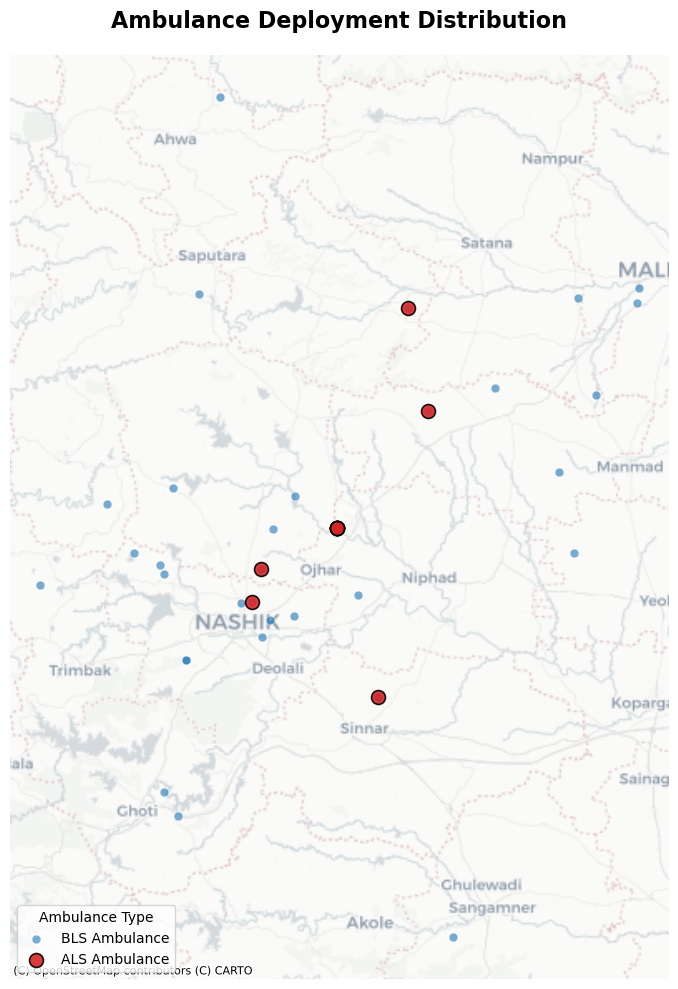

In [34]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

# 1. Load data
df = pd.read_csv("final_ambulance_deployment.csv")

# 2. Create a GeoDataFrame
# We use EPSG:4326 (standard lat/lon) and convert to EPSG:3857 (Web Mercator) 
# which is required for contextily tiles.
geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326").to_crs(epsg=3857)

# 3. Setup the plot
fig, ax = plt.subplots(figsize=(10, 12))

# Plot BLS (smaller, lighter markers)
gdf[gdf['type'] == 'BLS'].plot(
    ax=ax, 
    color='#1f77b4', 
    markersize=40, 
    alpha=0.6, 
    label='BLS Ambulance',
    edgecolor='white',
    linewidth=0.5
)

# Plot ALS (larger, bolder markers)
gdf[gdf['type'] == 'ALS'].plot(
    ax=ax, 
    color='#d62728', 
    markersize=100, 
    alpha=0.9, 
    label='ALS Ambulance',
    edgecolor='black',
    linewidth=1.2
)

# 4. Add the professional basemap (CartoDB Positron is very clean for reports)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# 5. Styling and Annotation
ax.set_axis_off()
plt.title("Ambulance Deployment Distribution", fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower left', frameon=True, fontsize=10, title="Ambulance Type")

# 6. Save at high resolution for your report
plt.savefig("ambulance_map_report.png", dpi=300, bbox_inches='tight')
plt.show()

In [38]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import Fullscreen, MarkerCluster

# Load data
amb_map_df = pd.read_csv("final_ambulance_deployment.csv")
print("Original type counts:")
print(amb_map_df["type"].value_counts())

# ------------------------------------------------------------
# 1. Add small jitter to ALL points (deterministic, tiny offset)
# ------------------------------------------------------------
np.random.seed(42)  # reproducible

# Jitter amount: ~50 meters (0.0005 degrees)
jitter_amount = 0.0005

amb_map_df["lat_jitter"] = amb_map_df["lat"] + np.random.uniform(
    -jitter_amount, jitter_amount, size=len(amb_map_df)
)
amb_map_df["lon_jitter"] = amb_map_df["lon"] + np.random.uniform(
    -jitter_amount, jitter_amount, size=len(amb_map_df)
)

# ------------------------------------------------------------
# 2. Separate BLS and ALS (now they both have jitter columns)
# ------------------------------------------------------------
bls_df = amb_map_df[amb_map_df["type"] == "BLS"].copy()
als_df = amb_map_df[amb_map_df["type"] == "ALS"].copy()

print(f"\nBLS to plot: {len(bls_df)}")
print(f"ALS to plot: {len(als_df)}")

# ------------------------------------------------------------
# 3. Create map
# ------------------------------------------------------------
center_lat = amb_map_df["lat"].median()
center_lon = amb_map_df["lon"].median()

m = folium.Map(location=[center_lat, center_lon], 
               zoom_start=11, 
               tiles="CartoDB positron")
Fullscreen().add_to(m)

# Marker clusters to handle overlapping points
bls_cluster = MarkerCluster(name="🚑 BLS Ambulances (clustered)", show=True).add_to(m)
als_cluster = MarkerCluster(name="🚨 ALS Ambulances (clustered)", show=True).add_to(m)

# ------------------------------------------------------------
# 4. Plot BLS (blue, smaller markers)
# ------------------------------------------------------------
for _, row in bls_df.iterrows():
    folium.CircleMarker(
        location=[row["lat_jitter"], row["lon_jitter"]],
        radius=5,
        color="#1f77b4",
        fill=True,
        fill_color="#1f77b4",
        fill_opacity=0.7,
        popup=f"<b>BLS {row['amb_id']}</b><br>Zone: {row['home_zone']}<br>Original: ({row['lat']:.5f}, {row['lon']:.5f})",
        tooltip=f"BLS {row['amb_id']} (Zone: {row['home_zone']})"
    ).add_to(bls_cluster)

# ------------------------------------------------------------
# 5. Plot ALS (red, larger, black border)
# ------------------------------------------------------------
for _, row in als_df.iterrows():
    folium.CircleMarker(
        location=[row["lat_jitter"], row["lon_jitter"]],
        radius=9,
        color="black",
        weight=2,
        fill=True,
        fill_color="#d62728",
        fill_opacity=0.9,
        popup=f"<b>🚨 ALS {row['amb_id']}</b><br>Zone: {row['home_zone']}<br>Original: ({row['lat']:.5f}, {row['lon']:.5f})",
        tooltip=f"ALS {row['amb_id']} (Zone: {row['home_zone']})"
    ).add_to(als_cluster)

# ------------------------------------------------------------
# 6. Legend with actual counts
# ------------------------------------------------------------
legend_html = f"""
<div style="position: fixed; bottom: 20px; right: 20px; background: rgba(255,255,255,0.95);
padding: 10px 15px; border-radius: 8px; box-shadow: 0 2px 8px rgba(0,0,0,0.2);
font-family: Arial; border-left: 4px solid #d62728;">
<b>🚑 Ambulance Types</b><br>
<span style="color:#1f77b4;">●</span> BLS: {len(bls_df)}<br>
<span style="color:#d62728;">●</span> ALS: {len(als_df)}<br>
<hr style="margin:4px 0">
<span style="font-size:11px;">🔍 Clusters expand on click<br>📍 Use +/- to zoom</span>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Layer control
folium.LayerControl(collapsed=False).add_to(m)

# ------------------------------------------------------------
# 7. Fit bounds to show all points
# ------------------------------------------------------------
bounds = [
    [amb_map_df["lat"].min(), amb_map_df["lon"].min()],
    [amb_map_df["lat"].max(), amb_map_df["lon"].max()]
]
m.fit_bounds(bounds, padding=(50, 50))

# ------------------------------------------------------------
# 8. Save and show
# ------------------------------------------------------------
m.save("ambulance_map_fixed.html")
print("\n✅ Map saved as 'ambulance_map_fixed.html'")
print(f"   Expected ALS markers: {len(als_df)}")

Original type counts:
type
BLS    35
ALS    11
Name: count, dtype: int64

BLS to plot: 35
ALS to plot: 11

✅ Map saved as 'ambulance_map_fixed.html'
   Expected ALS markers: 11
